In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================================
# COMPREHENSIVE CATBOOST HYPERPARAMETER TUNING - OPTIMIZED VERSION
# ============================================================================

# Import all necessary libraries
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import time
from datetime import datetime
import itertools
import pickle
import joblib
import json

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)

from sklearn.ensemble import RandomForestClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#from google.colab import files

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
plt.style.use('default')

print("="*80)
print("OPTIMIZED RANDOM FOREST HYPERPARAMETER TUNING PIPELINE")
print("="*80)
print("✅ All libraries imported successfully!")

OPTIMIZED RANDOM FOREST HYPERPARAMETER TUNING PIPELINE
✅ All libraries imported successfully!


In [3]:
file_path = "../dataset/01_feature_csv/TRAIN_StyleGAN.csv"
df = pd.read_csv(file_path)
print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")
print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ Dataset loaded successfully!
📊 Dataset shape: (12890, 2184)
💾 Memory usage: 216.56 MB


In [8]:
columns_to_drop = ['file_name', 'aspect_ratio', 'resolution', 'deep_embed_999']
original_cols = df.shape[1]
df = df.drop(columns=columns_to_drop, errors='ignore')
dropped = original_cols - df.shape[1]
if dropped > 0:
  print(f"🗑️ Dropped {dropped} columns")

print(f"Dataset Head: {df.head()}")
print(f"Dataset Info: {df.info()}")
print(df.columns.tolist())

🗑️ Dropped 1 columns
Dataset Head:    bit_depth_total  blue_channel_kurtosis  blue_channel_mean  \
0             24.0                  -0.79             121.78   
1             24.0                  -0.84             101.71   
2             24.0                  -1.04             104.44   
3             24.0                  -0.65             154.19   
4             24.0                  -0.94             154.09   

   blue_channel_skewness  blue_channel_std_dev  canny_edge_count  \
0                   0.28                 60.84            3973.0   
1                   0.40                 54.01            2743.0   
2                   0.27                 76.54            4690.0   
3                  -0.69                 62.85            3554.0   
4                  -0.12                 62.79            4579.0   

   canny_edge_density  color_hist_blue_0  color_hist_blue_1  \
0              0.0606              665.0              716.0   
1              0.0419               51.0     

In [9]:
target_column_name = 'class'

print(f"🎯 Target variable: '{target_column_name}'")

# Separate features and target
X = df.drop(target_column_name, axis=1)
y = df[target_column_name]

print(f"🎯 Target distribution:\n{y.value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=420)

print(f"✅ Dataset split: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples")

🎯 Target variable: 'class'
🎯 Target distribution:
class
2    7000
1    5890
Name: count, dtype: int64
✅ Dataset split: 10312 training samples, 2578 test samples


In [10]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Create all combinations of hyperparameters
param_combinations = list(itertools.product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['min_samples_split'],
    param_grid['min_samples_leaf'],
    param_grid['max_features'],
    param_grid['bootstrap']
))

print(f"🔍 Total hyperparameter combinations to try: {len(param_combinations)}")

🔍 Total hyperparameter combinations to try: 432


In [11]:
results = []
best_score = 0
best_model = None
best_params = None

for idx, params in enumerate(param_combinations):
    n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, bootstrap = params
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=420,
        n_jobs=-1,
        verbose=1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'params': params,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1
    })

    if f1 > best_score:
        best_score = f1
        best_model = model
        best_params = params

    print(f"[{idx+1}/{len(param_combinations)}] F1 Score: {f1:.4f} | Params: {params}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    5.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[1/432] F1 Score: 0.8361 | Params: (100, None, 2, 1, 'sqrt', True)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[2/432] F1 Score: 0.8376 | Params: (100, None, 2, 1, 'sqrt', False)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    1.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished


[431/432] F1 Score: 0.8191 | Params: (300, 30, 10, 4, 'log2', True)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    1.7s


[432/432] F1 Score: 0.8283 | Params: (300, 30, 10, 4, 'log2', False)


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    2.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished


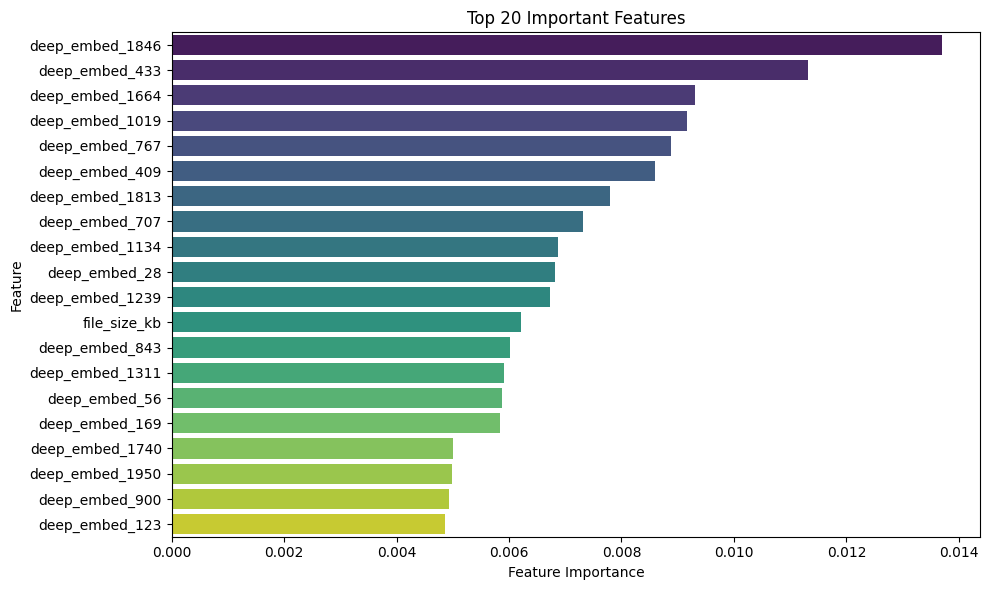

In [12]:
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title("Top 20 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [13]:
print("\n🏆 Best Model Parameters:")
print(f"n_estimators: {best_params[0]}")
print(f"max_depth: {best_params[1]}")
print(f"min_samples_split: {best_params[2]}")
print(f"min_samples_leaf: {best_params[3]}")
print(f"max_features: {best_params[4]}")
print(f"bootstrap: {best_params[5]}")

y_pred = best_model.predict(X_test)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("✅ Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


🏆 Best Model Parameters:
n_estimators: 200
max_depth: None
min_samples_split: 2
min_samples_leaf: 4
max_features: sqrt
bootstrap: False

📊 Classification Report:
               precision    recall  f1-score   support

           1       0.89      0.78      0.83      1178
           2       0.83      0.92      0.87      1400

    accuracy                           0.86      2578
   macro avg       0.86      0.85      0.85      2578
weighted avg       0.86      0.86      0.85      2578

✅ Confusion Matrix:
 [[ 915  263]
 [ 109 1291]]


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished


In [15]:
model_filename = f"03_combined_dataset_rf.joblib"
joblib.dump(best_model, model_filename)
print(f"✅ Best model saved locally as: {model_filename}")

'''
# Save to Google Drive
gdrive_path = f"../"
joblib.dump(best_model, gdrive_path)
print(f"✅ Best model also saved to Google Drive: {gdrive_path}")

# Download the model file
#files.download(gdrive_path)
#print("✅ Model downloaded successfully!")
'''

✅ Best model saved locally as: 03_combined_dataset_rf.joblib


'\n# Save to Google Drive\ngdrive_path = f"../"\njoblib.dump(best_model, gdrive_path)\nprint(f"✅ Best model also saved to Google Drive: {gdrive_path}")\n\n# Download the model file\n#files.download(gdrive_path)\n#print("✅ Model downloaded successfully!")\n'

# Testing

In [16]:
model = joblib.load("../models/03_combined_dataset_rf.joblib")
print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [18]:
test_df = pd.read_csv("../dataset/01_feature_csv/TEST_real_fake_hard.csv")
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1289 entries, 0 to 1288
Columns: 2184 entries, file_name to class
dtypes: float64(2176), int64(5), object(3)
memory usage: 21.5+ MB


In [19]:
print(test_df.head())

      file_name  aspect_ratio  bit_depth_total  blue_channel_kurtosis  \
0    real_1.jpg           1.0             24.0                  -1.01   
1   real_10.jpg           1.0             24.0                  -1.18   
2  real_100.jpg           1.0             24.0                   0.49   
3  real_101.jpg           1.0             24.0                   0.07   
4  real_102.jpg           1.0             24.0                   3.26   

   blue_channel_mean  blue_channel_skewness  blue_channel_std_dev  \
0              54.55                   0.43                 44.69   
1              71.10                   0.24                 42.54   
2              57.83                   0.19                 25.44   
3              67.09                   0.91                 34.69   
4              68.73                   2.01                 47.48   

   canny_edge_count  canny_edge_density  color_hist_blue_0  ...  \
0            3077.0              0.0342            19223.0  ...   
1           

In [20]:
test_df = test_df.drop(columns=columns_to_drop, errors='ignore')
#test_df = test_df.drop(columns='deep_embed_999', errors='ignore')

In [21]:
required = model.feature_names_in_
search_value = "0010 (10).jpg"
value_exists = test_df.isin([search_value]).any()

if value_exists:
    print(f"The value '{search_value}' exists in the DataFrame.")
else:
    print(f"The value '{search_value}' does not exist in the DataFrame.")

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1289 entries, 0 to 1288
Columns: 2180 entries, bit_depth_total to class
dtypes: float64(2175), int64(5)
memory usage: 21.4 MB


In [23]:
required = model.feature_names_in_
test_df_ordered = test_df[required]

print(test_df_ordered.head())

   bit_depth_total  blue_channel_kurtosis  blue_channel_mean  \
0             24.0                  -1.01              54.55   
1             24.0                  -1.18              71.10   
2             24.0                   0.49              57.83   
3             24.0                   0.07              67.09   
4             24.0                   3.26              68.73   

   blue_channel_skewness  blue_channel_std_dev  canny_edge_count  \
0                   0.43                 44.69            3077.0   
1                   0.24                 42.54            3403.0   
2                   0.19                 25.44            1541.0   
3                   0.91                 34.69            2298.0   
4                   2.01                 47.48            3994.0   

   canny_edge_density  color_hist_blue_0  color_hist_blue_1  \
0              0.0342            19223.0             7722.0   
1              0.0378              225.0             8311.0   
2              0.

In [24]:
'''
test_df['freq_domain_high_energy'] = 0
test_df['freq_domain_low_energy'] = 0
test_df['freq_domain_mid_energy'] = 0
test_df['deep_embed_999'] = 0
'''

# Separate features and target
X_test = test_df_ordered
y_test = test_df['class']

print(X_test.head())
print(y_test.head())
print(f"Columns: {X_test.columns.tolist()}")

   bit_depth_total  blue_channel_kurtosis  blue_channel_mean  \
0             24.0                  -1.01              54.55   
1             24.0                  -1.18              71.10   
2             24.0                   0.49              57.83   
3             24.0                   0.07              67.09   
4             24.0                   3.26              68.73   

   blue_channel_skewness  blue_channel_std_dev  canny_edge_count  \
0                   0.43                 44.69            3077.0   
1                   0.24                 42.54            3403.0   
2                   0.19                 25.44            1541.0   
3                   0.91                 34.69            2298.0   
4                   2.01                 47.48            3994.0   

   canny_edge_density  color_hist_blue_0  color_hist_blue_1  \
0              0.0342            19223.0             7722.0   
1              0.0378              225.0             8311.0   
2              0.

In [25]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("✅ Predictions completed!")
print(f"Sample predictions: {y_pred[:5]}")

✅ Predictions completed!
Sample predictions: [2 1 1 2 1]


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished


In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n📊 Test Set Evaluation Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
print("\n📋 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Classification Report
print("\n📑 Classification Report:")
print(classification_report(y_test, y_pred))


📊 Test Set Evaluation Results:
Accuracy: 0.9123
Precision: 0.9139
Recall: 0.9123
F1 Score: 0.9120

📋 Confusion Matrix:
[[510  79]
 [ 34 666]]

📑 Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.87      0.90       589
           2       0.89      0.95      0.92       700

    accuracy                           0.91      1289
   macro avg       0.92      0.91      0.91      1289
weighted avg       0.91      0.91      0.91      1289



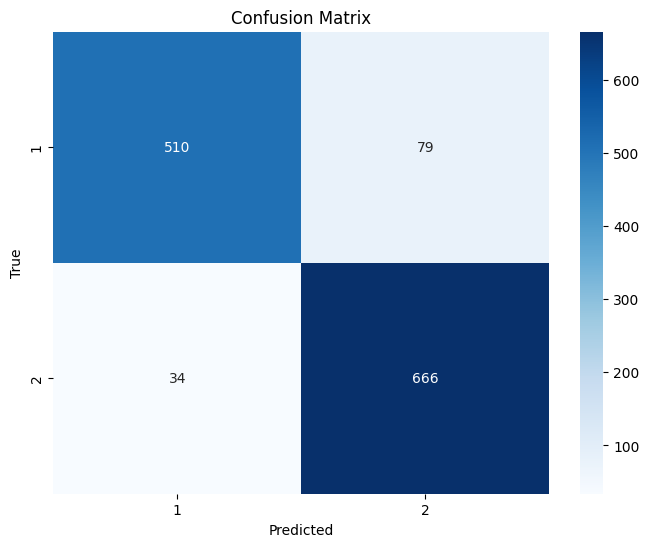

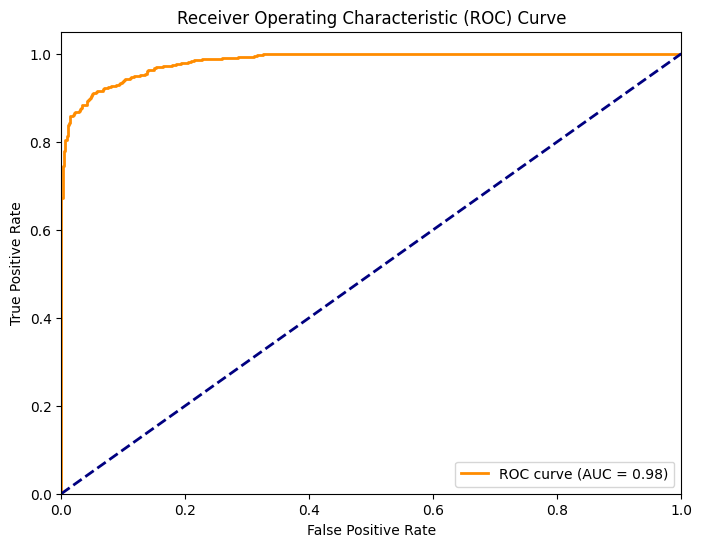

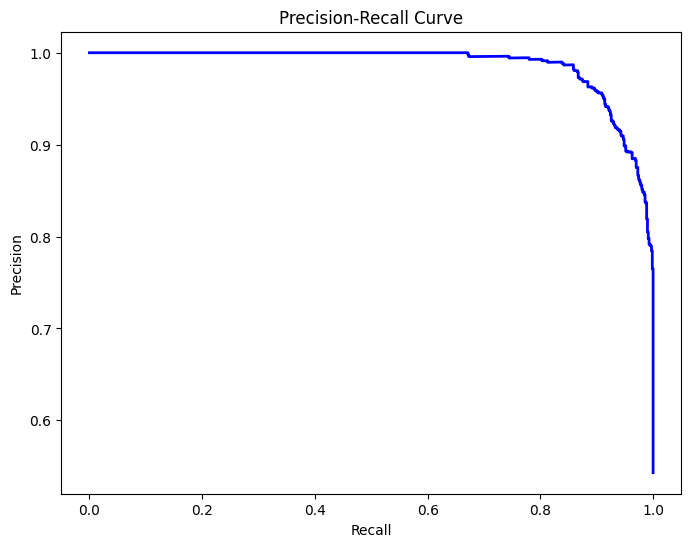

✅ Visualizations completed!


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Get unique class names (assuming y_test is categorical or encoded)
class_names = sorted(np.unique(y_test))

# Plot confusion matrix
plot_confusion_matrix(cm, class_names)

# If binary classification, plot ROC Curve
n_classes = len(class_names)
if n_classes == 2:
    # Binarize y_test for binary case
    y_test_bin = label_binarize(y_test, classes=class_names)
    fpr, tpr, _ = roc_curve(y_test_bin, y_pred_proba[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin, y_pred_proba[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(recall_curve, precision_curve, color='blue', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()
elif n_classes > 2:
    print("⚠️ ROC and Precision-Recall curves shown for binary classification only. For multi-class, consider one-vs-rest plots.")

"""
# Feature Importance Visualization
print("\n⭐ Feature Importance Visualization:")
# Drop the problematic column from X_test before getting feature names
X_test_for_importance = X_test.drop(columns='deep_embed_999', errors='ignore')
importances = pd.Series(model.get_feature_importance(), index=X_test_for_importance.columns)
importances_sorted = importances.sort_values(ascending=False).head(20)  # Top 20 features

plt.figure(figsize=(10, 8))
importances_sorted.plot(kind='barh')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.show()
"""

print("✅ Visualizations completed!")